# **Section 1: Setup & Data Loading**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
pd.set_option('display.max_columns', None)

In [ ]:
# Load Datasets
patient_df = pd.read_csv('patient_journey.csv')
provider_df = pd.read_csv('provider_master.csv')
comm_df = pd.read_csv('communication_logs.csv')
country_df = pd.read_csv('country_reference.csv')
treatment_df = pd.read_csv('treatment_outcomes.csv')

In [ ]:
# Convert Dates
patient_df['inquiry_date'] = pd.to_datetime(
    patient_df['inquiry_date']
)
comm_df['timestamp'] = pd.to_datetime(
    comm_df['timestamp']
)
treatment_df['treatment_date'] = pd.to_datetime(
    treatment_df['treatment_date']
)

# **Section 2: Funnel Analysis**
Inquiry
   →
Consultation Booked
   →
Quote Shared
   →
Treatment Completed

2.1 Calculate Funnel Numbers

In [ ]:
total_inquiries = len(patient_df)
consultations = patient_df[
    patient_df['consultation_booked'] == 1
].shape[0]
quotes = patient_df[
    patient_df['quote_shared'] == 1
].shape[0]
completed = patient_df[
    patient_df['treatment_completed'] == 1
].shape[0]
funnel_df = pd.DataFrame({
    'Stage': [
        'Inquiries',
        'Consultations',
        'Quotes Shared',
        'Treatment Completed'
    ],
    'Count': [
        total_inquiries,
        consultations,
        quotes,
        completed
    ]
})
display(funnel_df)

,Stage,Count
0,Inquiries,1500
1,Consultations,984
2,Quotes Shared,561
3,Treatment Completed,554


2.2 Funnel Visualization

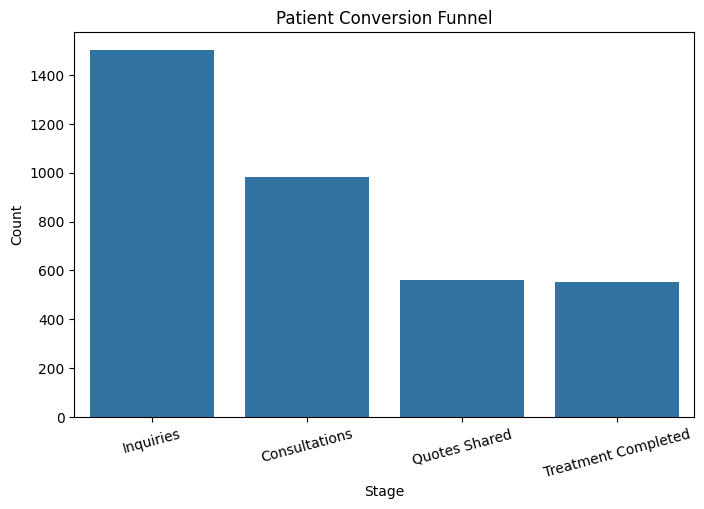

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=funnel_df,
    x='Stage',
    y='Count'
)
plt.title("Patient Conversion Funnel")
plt.xticks(rotation=15)
plt.show()

2.3 Funnel Conversion Rates

In [ ]:
consultation_rate = (
    consultations / total_inquiries
) * 100
quote_rate = (
    quotes / total_inquiries
) * 100
completion_rate = (
    completed / total_inquiries
) * 100
print(f"Consultation Conversion Rate: {consultation_rate:.2f}%")
print(f"Quote Share Rate: {quote_rate:.2f}%")
print(f"Treatment Completion Rate: {completion_rate:.2f}%")

Consultation Conversion Rate: 65.60%
Quote Share Rate: 37.40%
Treatment Completion Rate: 36.93%


2.4 Stage-to-Stage Conversion

In [ ]:
consult_to_quote = (
    quotes / consultations
) * 100
quote_to_treatment = (
    completed / quotes
) * 100
print(f"Consultation → Quote: {consult_to_quote:.2f}%")
print(f"Quote → Treatment: {quote_to_treatment:.2f}%")

Consultation → Quote: 57.01%
Quote → Treatment: 98.75%


2.5 Funnel Drop-offs

In [ ]:
dropoff_df = pd.DataFrame({
    'Stage': [
        'Inquiry to Consultation',
        'Consultation to Quote',
        'Quote to Treatment'
    ],
    'Drop-offs': [
        total_inquiries - consultations,
        consultations - quotes,
        quotes - completed
    ]
})
display(dropoff_df)

,Stage,Drop-offs
0,Inquiry to Consultation,516
1,Consultation to Quote,423
2,Quote to Treatment,7


2.6 Drop-off Visualization

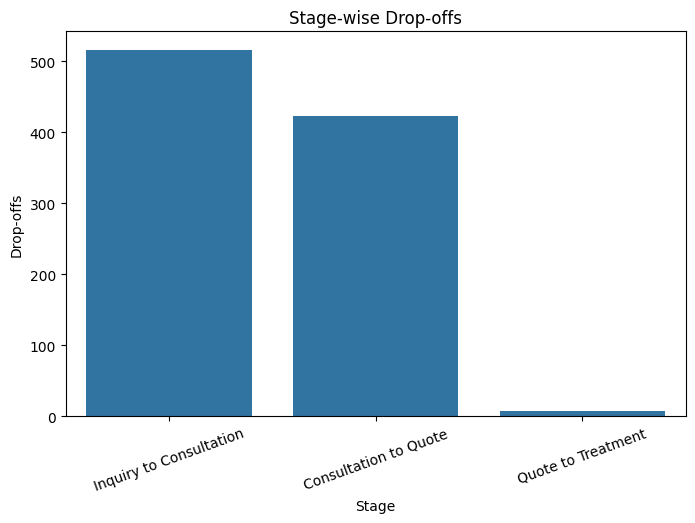

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=dropoff_df,
    x='Stage',
    y='Drop-offs'
)
plt.title("Stage-wise Drop-offs")
plt.xticks(rotation=20)
plt.show()

# **Observations**
## Funnel Analysis Insights

- Total patient inquiries: XXXX
- XX% of inquiries converted into consultations.
- XX% of inquiries received quotes.
- XX% completed treatment.
- Largest drop-off occurred between ______ and ______ stage.
- Funnel highlights the primary bottleneck in the patient journey.

# **Section 3: Drop-off Analysis**

3.1 Overall Drop-off Stage Distribution

In [ ]:
print("="*60)
print("DROP-OFF STAGE DISTRIBUTION")
print("="*60)
dropoff_stage = patient_df['drop_off_stage'].value_counts()
display(dropoff_stage)

DROP-OFF STAGE DISTRIBUTION


,count
drop_off_stage,
Inquiry,103
First Response,89
Consultation,55
Treatment Plan,49
Quote Shared,43
Travel Planning,11


3.2 Drop-off Stage Visualization

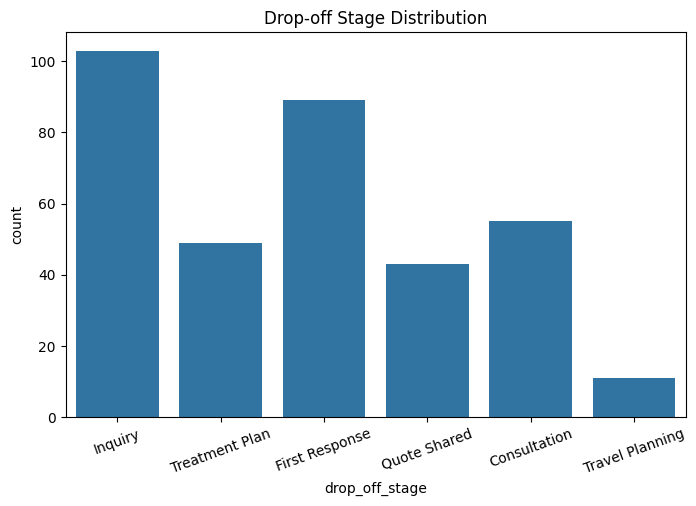

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=patient_df,
    x='drop_off_stage'
)
plt.title('Drop-off Stage Distribution')
plt.xticks(rotation=20)
plt.show()

3.3 Drop-off Percentage by Stage

In [ ]:
dropoff_percentage = (
    patient_df['drop_off_stage']
    .value_counts(normalize=True)
    * 100
)
display(dropoff_percentage.round(2))

,proportion
drop_off_stage,
Inquiry,29.43
First Response,25.43
Consultation,15.71
Treatment Plan,14.00
Quote Shared,12.29
Travel Planning,3.14


# Country-wise Drop-off Analysis
3.4 Country-wise Drop-offs

In [ ]:
country_dropoff = pd.crosstab(
    patient_df['country'],
    patient_df['drop_off_stage']
)
display(country_dropoff)

drop_off_stage,Consultation,First Response,Inquiry,Quote Shared,Travel Planning,Treatment Plan
country,,,,,,
Bangladesh,6,5,11,3,0,10
India,3,5,6,3,2,0
Kenya,7,9,7,2,1,2
Malaysia,4,7,8,3,2,6
Nepal,4,6,9,5,2,3
Nigeria,4,11,7,3,0,6
Oman,2,10,11,1,0,2
Philippines,5,6,13,5,0,5
Sri Lanka,1,4,9,7,1,2


3.5 Country-wise Visualization

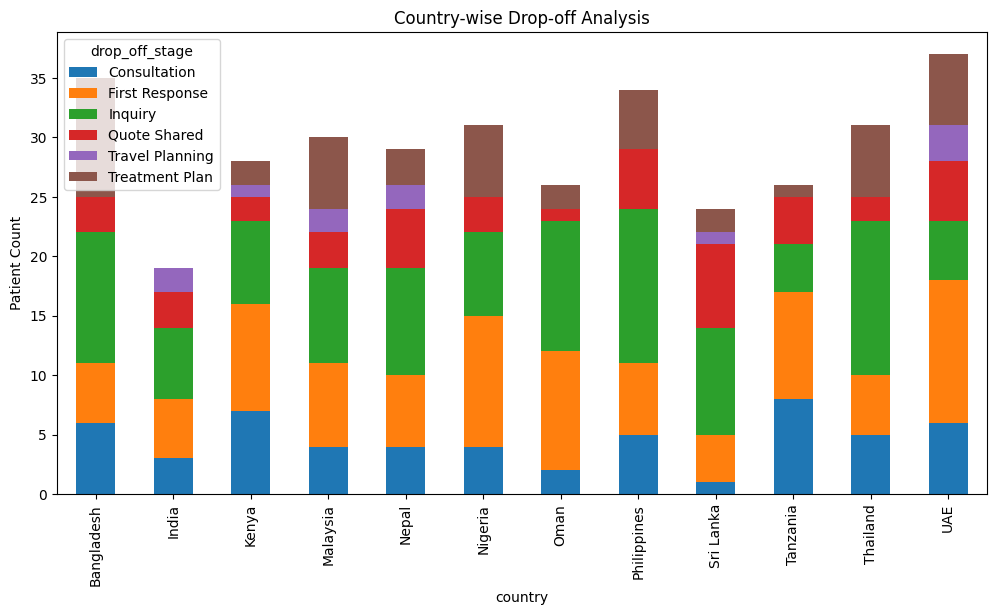

In [ ]:
country_dropoff.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)
plt.title('Country-wise Drop-off Analysis')
plt.ylabel('Patient Count')
plt.show()

3.6 Top Countries with Highest Drop-offs

In [ ]:
country_drop_summary = (
    patient_df.groupby('country')
    .size()
    .sort_values(ascending=False)
)
display(country_drop_summary)

,0
country,
UAE,143
Philippines,141
Bangladesh,136
Nepal,133
Malaysia,130
Oman,130
Kenya,126
Tanzania,120
Nigeria,117


# Treatment Category-wise Drop-off Analysis
3.7 Treatment Category vs Drop-off

In [ ]:
treatment_dropoff = pd.crosstab(
    patient_df['treatment_category'],
    patient_df['drop_off_stage']
)
display(treatment_dropoff)

drop_off_stage,Consultation,First Response,Inquiry,Quote Shared,Travel Planning,Treatment Plan
treatment_category,,,,,,
Bariatric Surgery,4,9,10,9,0,4
Cardiology,7,8,6,5,1,7
Cosmetic Surgery,9,15,11,2,3,6
Dental,4,10,16,3,0,5
Fertility,5,10,12,8,4,7
Neurology,10,13,11,3,0,2
Oncology,5,9,12,4,0,6
Orthopedics,4,8,14,3,2,7
Transplant Evaluation,7,7,11,6,1,5


3.8 Treatment Category Visualization

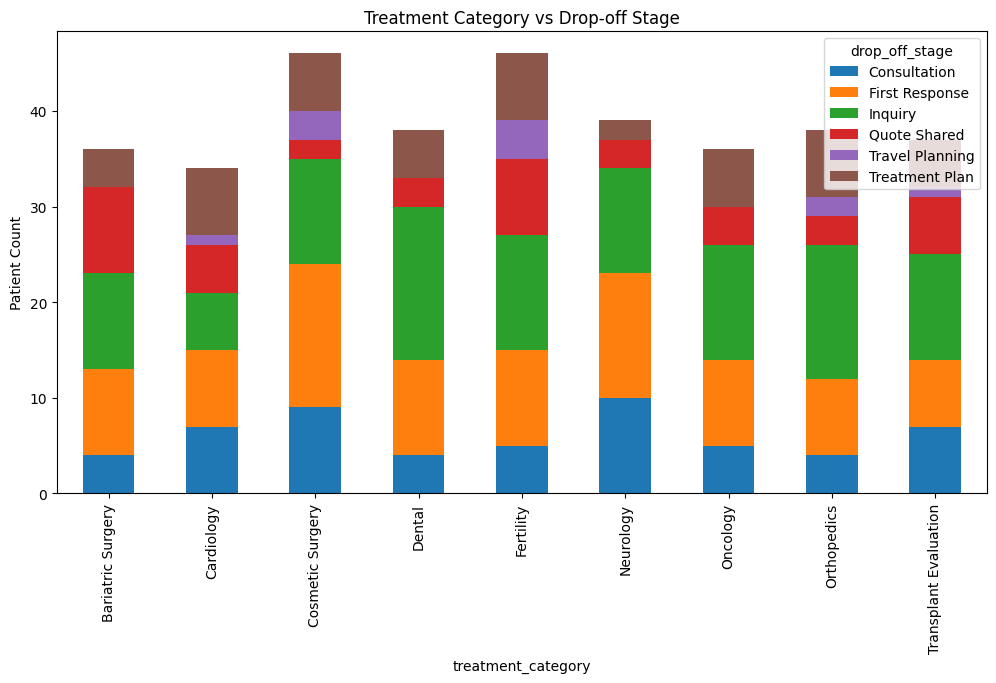

In [ ]:
treatment_dropoff.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)
plt.title(
    'Treatment Category vs Drop-off Stage'
)
plt.ylabel('Patient Count')
plt.show()

# Lead Source Drop-off Analysis
3.9 Lead Source vs Drop-off

In [ ]:
lead_dropoff = pd.crosstab(
    patient_df['lead_source'],
    patient_df['drop_off_stage']
)
display(lead_dropoff)

drop_off_stage,Consultation,First Response,Inquiry,Quote Shared,Travel Planning,Treatment Plan
lead_source,,,,,,
Chatbot,12,14,14,9,0,8
Email,8,16,11,4,2,4
Phone,4,12,25,10,2,9
Referral Partner,10,18,19,1,3,12
Web Form,9,17,21,10,2,8
WhatsApp,12,12,13,9,2,8


3.10 Lead Source Visualization

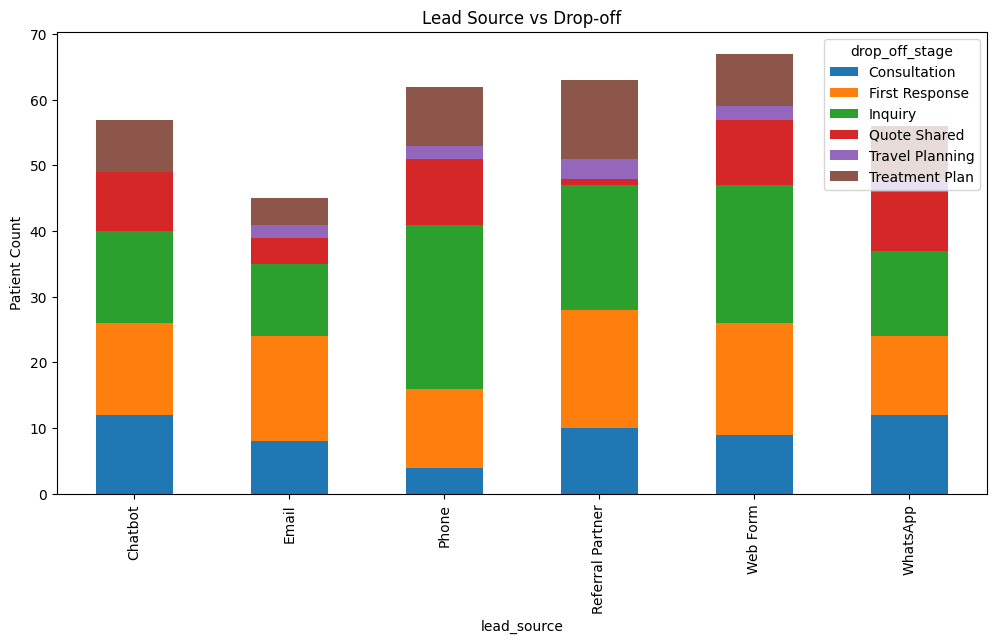

In [ ]:
lead_dropoff.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)
plt.title('Lead Source vs Drop-off')
plt.ylabel('Patient Count')
plt.show()

# Response Time vs Drop-off
3.11 Average Response Time by Drop-off Stage

In [ ]:
response_dropoff = (
    patient_df.groupby('drop_off_stage')
    ['response_time_hours']
    .mean()
    .sort_values(ascending=False)
)
display(response_dropoff)

,response_time_hours
drop_off_stage,
Quote Shared,22.502326
Treatment Plan,21.210204
Travel Planning,20.845455
Consultation,20.660000
First Response,20.025843
Inquiry,19.523301


3.12 Visualization

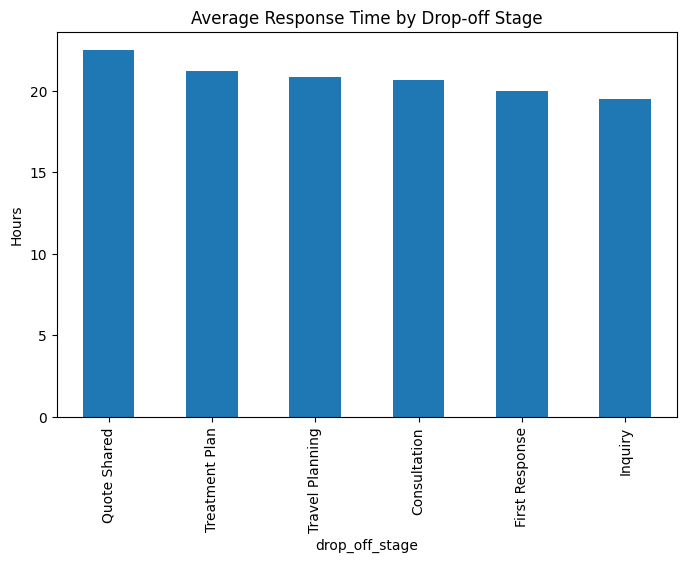

In [ ]:
plt.figure(figsize=(8,5))
response_dropoff.plot(
    kind='bar'
)
plt.title(
    'Average Response Time by Drop-off Stage'
)
plt.ylabel('Hours')
plt.show()

# Engagement Score vs Drop-off
3.13 Engagement Score Analysis

In [ ]:
engagement_dropoff = (
    patient_df.groupby('drop_off_stage')
    ['engagement_score']
    .mean()
)
display(engagement_dropoff)

,engagement_score
drop_off_stage,
Consultation,42.081818
First Response,43.075281
Inquiry,39.687379
Quote Shared,40.344186
Travel Planning,45.390909
Treatment Plan,44.187755


3.14 Visualization

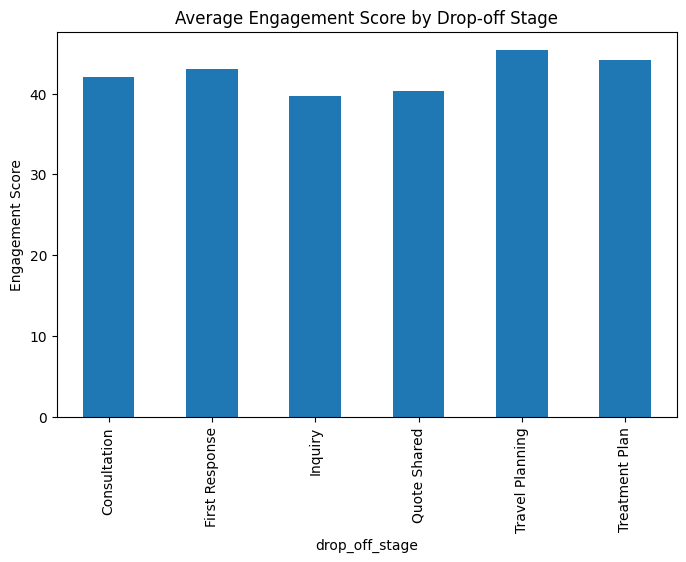

In [ ]:
plt.figure(figsize=(8,5))
engagement_dropoff.plot(
    kind='bar'
)
plt.title(
    'Average Engagement Score by Drop-off Stage'
)
plt.ylabel('Engagement Score')
plt.show()

# Key Drop-off Summary Table
3.15 Summary

In [ ]:
dropoff_summary = pd.DataFrame({
    'Metric': [
        'Total Patients',
        'Patients Dropped'
    ],
    'Value': [
        len(patient_df),
        patient_df['drop_off_stage']
        .notna()
        .sum()
    ]
})
display(dropoff_summary)

,Metric,Value
0,Total Patients,1500
1,Patients Dropped,350


# **Observations**
## Drop-off Analysis Insights

- Most patient losses occur at the ______ stage.
- Certain countries show significantly higher drop-off rates.
- Some treatment categories experience lower conversion performance.
- Higher response times are associated with increased drop-offs.
- Patients with lower engagement scores are more likely to disengage.

### Recommendation

- Prioritize follow-ups in high drop-off stages.
- Improve response times for at-risk patient groups.
- Create country-specific engagement strategies.
- Focus coordinator efforts on low-engagement patients.

# **Section 4: Provider Performance Analysis**
4.1 Provider-wise Patient Count

In [ ]:
provider_patient_count = (
    patient_df.groupby('provider_id')
    .size()
    .reset_index(name='patient_count')
)
display(
    provider_patient_count
    .sort_values(by='patient_count', ascending=False)
)

,provider_id,patient_count
3,PVD-004,66
2,PVD-003,59
11,PVD-012,58
8,PVD-009,56
14,PVD-015,56
0,PVD-001,55
19,PVD-020,55
7,PVD-008,55
26,PVD-027,53
13,PVD-014,52


4.2 Provider-wise Treatment Completion Rate

In [ ]:
provider_conversion = (
    patient_df.groupby('provider_id')
    ['treatment_completed']
    .mean()
    .reset_index()
)
provider_conversion['conversion_rate'] = (
    provider_conversion['treatment_completed'] * 100
)
provider_conversion = provider_conversion[
    ['provider_id', 'conversion_rate']
]
display(
    provider_conversion
    .sort_values(by='conversion_rate', ascending=False)
)

,provider_id,conversion_rate
19,PVD-020,52.727273
6,PVD-007,52.000000
7,PVD-008,50.909091
0,PVD-001,47.272727
10,PVD-011,46.938776
16,PVD-017,46.511628
14,PVD-015,46.428571
2,PVD-003,44.067797
21,PVD-022,42.553191
20,PVD-021,41.176471


4.3 Top 10 Providers by Conversion Rate

In [ ]:
top_conversion = (
    provider_conversion
    .sort_values(
        by='conversion_rate',
        ascending=False
    )
    .head(10)
)
display(top_conversion)

,provider_id,conversion_rate
19,PVD-020,52.727273
6,PVD-007,52.000000
7,PVD-008,50.909091
0,PVD-001,47.272727
10,PVD-011,46.938776
16,PVD-017,46.511628
14,PVD-015,46.428571
2,PVD-003,44.067797
21,PVD-022,42.553191
20,PVD-021,41.176471


4.4 Conversion Rate Visualization

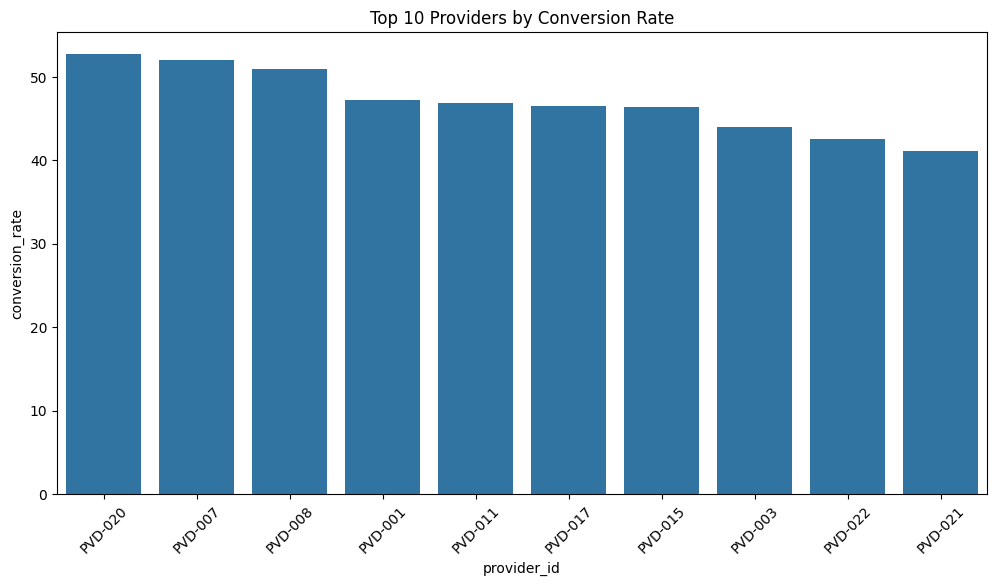

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=top_conversion,
    x='provider_id',
    y='conversion_rate'
)
plt.title('Top 10 Providers by Conversion Rate')
plt.xticks(rotation=45)
plt.show()

4.5 Average Response Time by Provider

In [ ]:
provider_response = (
    patient_df.groupby('provider_id')
    ['response_time_hours']
    .mean()
    .reset_index()
)
display(
    provider_response
    .sort_values(
        by='response_time_hours'
    )
)

,provider_id,response_time_hours
19,PVD-020,5.854545
7,PVD-008,10.280000
20,PVD-021,11.041176
23,PVD-024,12.182692
14,PVD-015,12.510714
21,PVD-022,13.344681
10,PVD-011,13.563265
2,PVD-003,14.893220
26,PVD-027,14.971698
16,PVD-017,15.230233


4.6 Best SLA Performers

In [ ]:
best_response = (
    provider_response
    .sort_values(
        by='response_time_hours'
    )
    .head(10)
)
display(best_response)

,provider_id,response_time_hours
19,PVD-020,5.854545
7,PVD-008,10.280000
20,PVD-021,11.041176
23,PVD-024,12.182692
14,PVD-015,12.510714
21,PVD-022,13.344681
10,PVD-011,13.563265
2,PVD-003,14.893220
26,PVD-027,14.971698
16,PVD-017,15.230233


4.7 Response Time Visualization

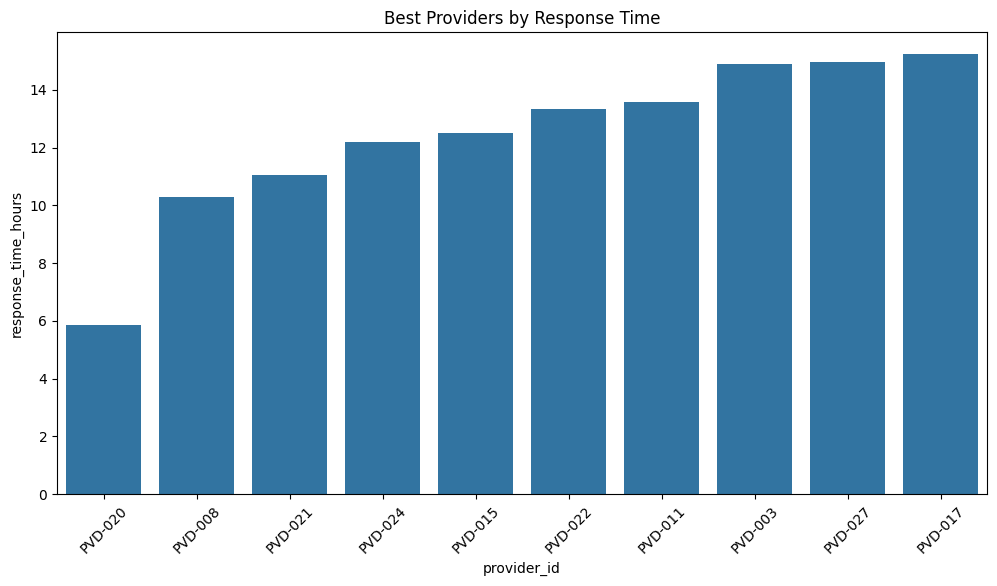

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=best_response,
    x='provider_id',
    y='response_time_hours'
)
plt.title('Best Providers by Response Time')
plt.xticks(rotation=45)
plt.show()

4.8 Provider-wise Satisfaction Score

In [ ]:
provider_satisfaction = (
    patient_df.groupby('provider_id')
    ['engagement_score']
    .mean()
    .reset_index()
)
display(
    provider_satisfaction
    .sort_values(
        by='engagement_score',
        ascending=False
    )
)

,provider_id,engagement_score
19,PVD-020,61.843636
7,PVD-008,61.052727
21,PVD-022,59.800000
10,PVD-011,59.004082
16,PVD-017,58.553488
2,PVD-003,58.506780
14,PVD-015,57.621429
23,PVD-024,57.448077
20,PVD-021,57.066667
6,PVD-007,55.846000


4.9 Top Providers by Satisfaction

In [ ]:
top_satisfaction = (
    provider_satisfaction
    .sort_values(
        by='engagement_score',
        ascending=False
    )
    .head(10)
)
display(top_satisfaction)

,provider_id,engagement_score
19,PVD-020,61.843636
7,PVD-008,61.052727
21,PVD-022,59.800000
10,PVD-011,59.004082
16,PVD-017,58.553488
2,PVD-003,58.506780
14,PVD-015,57.621429
23,PVD-024,57.448077
20,PVD-021,57.066667
6,PVD-007,55.846000


4.10 Provider Revenue Analysis

In [ ]:
provider_revenue = (
    treatment_df.groupby('provider_id')
    ['actual_revenue_inr']
    .sum()
    .reset_index()
)
display(
    provider_revenue
    .sort_values(
        by='actual_revenue_inr',
        ascending=False
    )
)

,provider_id,actual_revenue_inr
7,PVD-008,13774849
19,PVD-020,13379748
14,PVD-015,13251837
6,PVD-007,12239804
0,PVD-001,12202774
2,PVD-003,10342004
3,PVD-004,9991089
26,PVD-027,9829155
8,PVD-009,9577002
20,PVD-021,9162836


4.11 Top Revenue Generating Providers

In [ ]:
top_revenue_provider = (
    provider_revenue
    .sort_values(
        by='actual_revenue_inr',
        ascending=False
    )
    .head(10)
)
display(top_revenue_provider)

,provider_id,actual_revenue_inr
7,PVD-008,13774849
19,PVD-020,13379748
14,PVD-015,13251837
6,PVD-007,12239804
0,PVD-001,12202774
2,PVD-003,10342004
3,PVD-004,9991089
26,PVD-027,9829155
8,PVD-009,9577002
20,PVD-021,9162836


4.12 Revenue Visualization

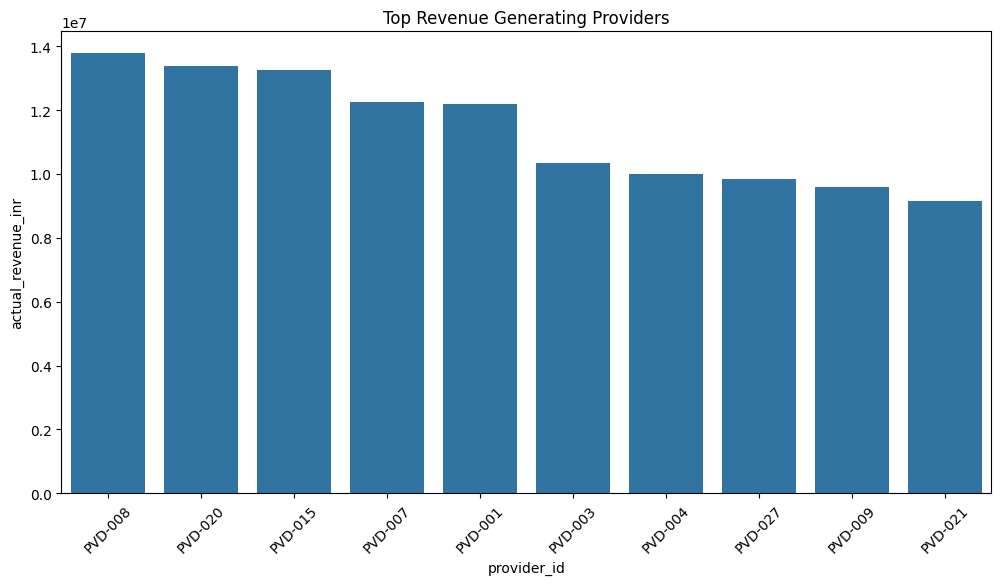

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=top_revenue_provider,
    x='provider_id',
    y='actual_revenue_inr'
)
plt.title(
    'Top Revenue Generating Providers'
)
plt.xticks(rotation=45)
plt.show()

4.13 Provider Performance Scorecard

In [ ]:
provider_scorecard = (
    provider_conversion
    .merge(
        provider_response,
        on='provider_id'
    )
    .merge(
        provider_satisfaction,
        on='provider_id'
    )
)
display(provider_scorecard.head())

,provider_id,conversion_rate,response_time_hours,engagement_score
0,PVD-001,47.272727,16.783636,49.949091
1,PVD-002,40.476190,18.035714,51.928571
2,PVD-003,44.067797,14.893220,58.506780
3,PVD-004,36.363636,19.216667,53.718182
4,PVD-005,27.083333,23.008333,46.808333


4.14 Correlation Analysis

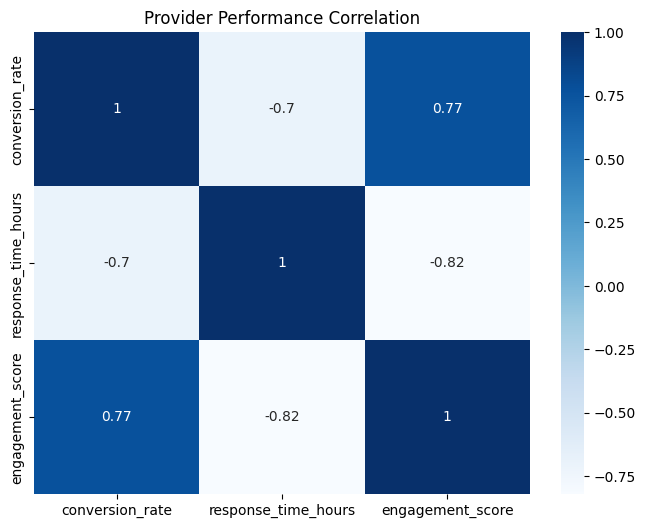

In [ ]:
provider_scorecard.corr(
    numeric_only=True
)
# Visualization:
plt.figure(figsize=(8,6))
sns.heatmap(
    provider_scorecard.corr(
        numeric_only=True
    ),
    annot=True,
    cmap='Blues'
)
plt.title(
    'Provider Performance Correlation'
)
plt.show()

# **Observations**
## Provider Performance Insights

- Several providers consistently outperform others in conversion rate.
- Faster response times generally correspond to better patient outcomes.
- High satisfaction providers tend to achieve stronger treatment completion rates.
- Revenue contribution is concentrated among a small number of providers.

### Recommendation

- Prioritize high-performing providers.
- Review workflow of low-conversion providers.
- Replicate best practices from top-performing providers.
- Use provider scorecards for partner performance reviews.

# **Section 5: Country & Market Analysis**
5.1 Patient Distribution by Country

In [ ]:
country_patients = (
    patient_df.groupby('country')
    .size()
    .reset_index(name='patient_count')
    .sort_values(
        by='patient_count',
        ascending=False
    )
)
display(country_patients)

,country,patient_count
11,UAE,143
7,Philippines,141
0,Bangladesh,136
4,Nepal,133
3,Malaysia,130
6,Oman,130
2,Kenya,126
9,Tanzania,120
5,Nigeria,117
8,Sri Lanka,116


5.2 Country-wise Patient Distribution Chart

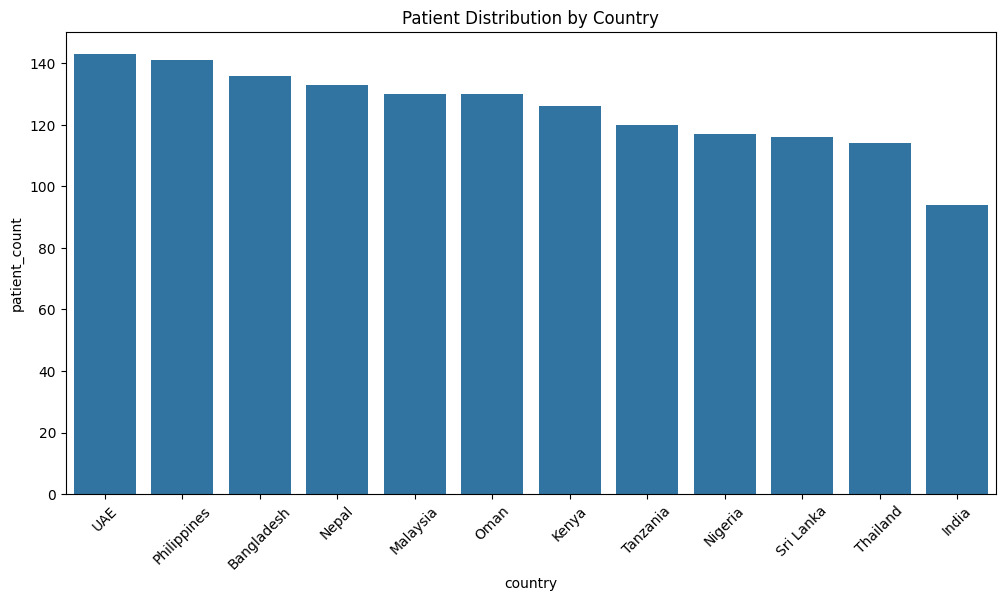

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=country_patients,
    x='country',
    y='patient_count'
)
plt.title('Patient Distribution by Country')
plt.xticks(rotation=45)
plt.show()

5.3 Country-wise Consultation Conversion Rate

In [ ]:
country_consultation = (
    patient_df.groupby('country')
    ['consultation_booked']
    .mean()
    .reset_index()
)
country_consultation[
    'consultation_rate'
] = (
    country_consultation[
        'consultation_booked'
    ] * 100
)
display(
    country_consultation.sort_values(
        by='consultation_rate',
        ascending=False
    )
)

,country,consultation_booked,consultation_rate
9,Tanzania,0.700000,70.000000
0,Bangladesh,0.683824,68.382353
8,Sri Lanka,0.681034,68.103448
10,Thailand,0.675439,67.543860
1,India,0.670213,67.021277
3,Malaysia,0.669231,66.923077
4,Nepal,0.654135,65.413534
6,Oman,0.646154,64.615385
11,UAE,0.643357,64.335664
2,Kenya,0.634921,63.492063


5.4 Country-wise Treatment Completion Rate

In [ ]:
country_completion = (
    patient_df.groupby('country')
    ['treatment_completed']
    .mean()
    .reset_index()
)
country_completion[
    'completion_rate'
] = (
    country_completion[
        'treatment_completed'
    ] * 100
)
display(
    country_completion.sort_values(
        by='completion_rate',
        ascending=False
    )
)

,country,treatment_completed,completion_rate
2,Kenya,0.444444,44.444444
3,Malaysia,0.415385,41.538462
11,UAE,0.391608,39.160839
6,Oman,0.376923,37.692308
0,Bangladesh,0.375000,37.500000
7,Philippines,0.368794,36.879433
1,India,0.361702,36.170213
8,Sri Lanka,0.353448,35.344828
4,Nepal,0.353383,35.338346
10,Thailand,0.350877,35.087719


5.5 Completion Rate Visualization

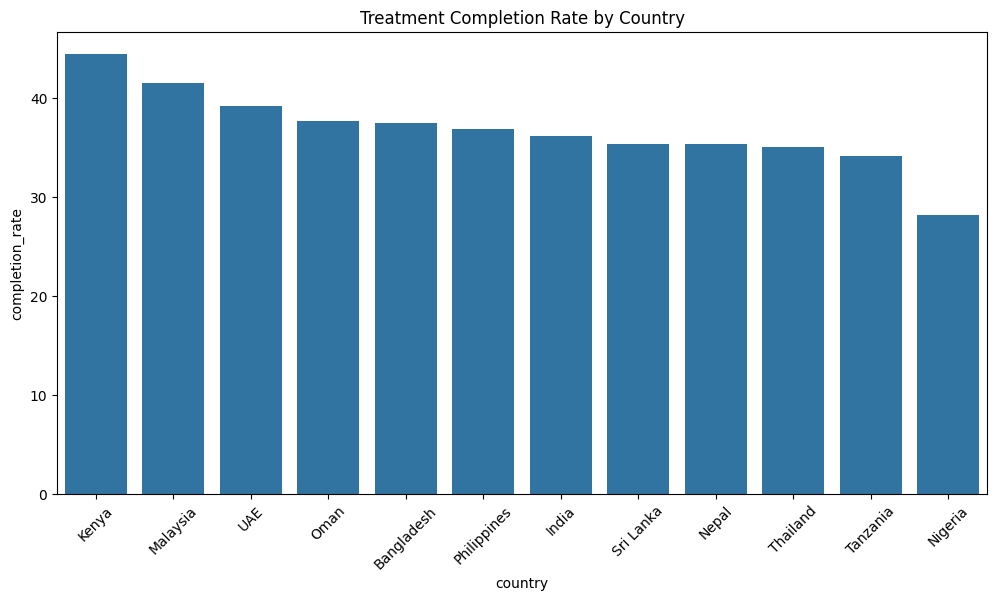

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=country_completion.sort_values(
        by='completion_rate',
        ascending=False
    ),
    x='country',
    y='completion_rate'
)
plt.title(
    'Treatment Completion Rate by Country'
)
plt.xticks(rotation=45)
plt.show()

5.6 Country-wise Revenue Analysis

In [ ]:
country_revenue = (
    patient_df.groupby('country')
    ['actual_revenue_inr']
    .sum()
    .reset_index()
)

display(
    country_revenue.sort_values(
        by='actual_revenue_inr',
        ascending=False
    )
)

,country,actual_revenue_inr
7,Philippines,26747162
3,Malaysia,24068255
11,UAE,23152586
0,Bangladesh,22489480
4,Nepal,22316451
2,Kenya,21950483
6,Oman,21628726
10,Thailand,20285568
8,Sri Lanka,18580469
9,Tanzania,17297216


5.7 Top Revenue Countries

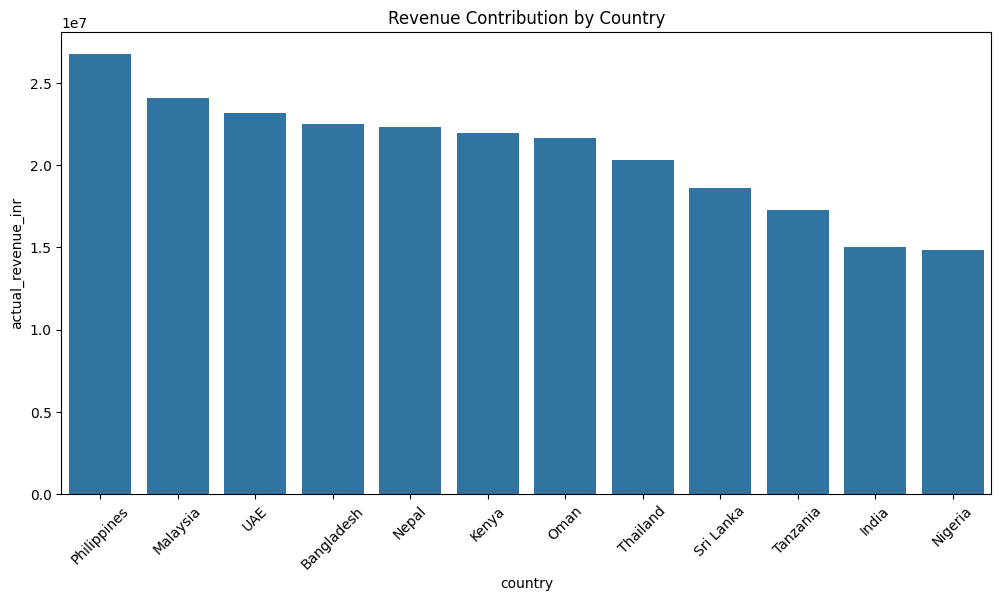

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=country_revenue.sort_values(
        by='actual_revenue_inr',
        ascending=False
    ),
    x='country',
    y='actual_revenue_inr'
)
plt.title(
    'Revenue Contribution by Country'
)
plt.xticks(rotation=45)
plt.show()

5.8 Merge with Country Reference

In [ ]:
country_analysis = (
    country_completion.merge(
        country_df,
        on='country',
        how='left'
    )
)
display(country_analysis.head())

,country,treatment_completed,completion_rate,region,avg_travel_lead_time_days,requires_medical_visa,currency,baseline_response_expectation_hours,market_priority_score
0,Bangladesh,0.375000,37.500000,Middle East,27,Yes,USD,12,57
1,India,0.361702,36.170213,Middle East,36,Yes,AED,8,81
2,Kenya,0.444444,44.444444,East Africa,14,No,KES,12,89
3,Malaysia,0.415385,41.538462,West Africa,14,Case-dependent,KES,8,62
4,Nepal,0.353383,35.338346,West Africa,42,Yes,MYR,6,71


5.9 Priority Score vs Completion Rate

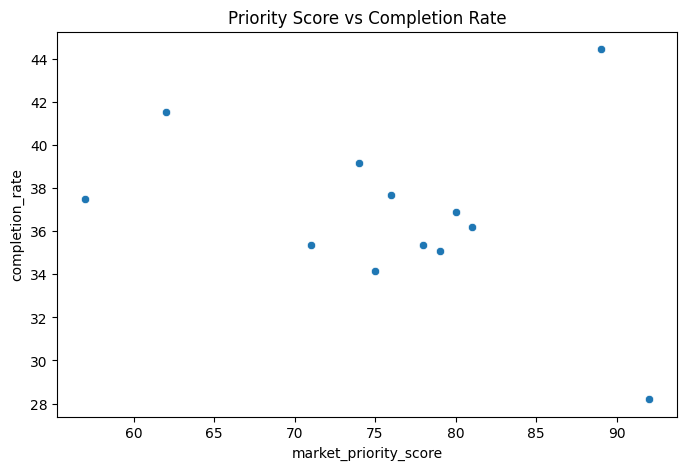

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=country_analysis,
    x='market_priority_score',
    y='completion_rate'
)
plt.title(
    'Priority Score vs Completion Rate'
)
plt.show()

5.10 Region-wise Analysis

In [ ]:
region_analysis = (
    country_analysis.groupby('region')
    ['completion_rate']
    .mean()
    .reset_index()
)
display(region_analysis)

,region,completion_rate
0,East Africa,35.756678
1,Middle East,37.120840
2,South Asia,35.344828
3,West Africa,38.679216


5.11 Region-wise Visualization

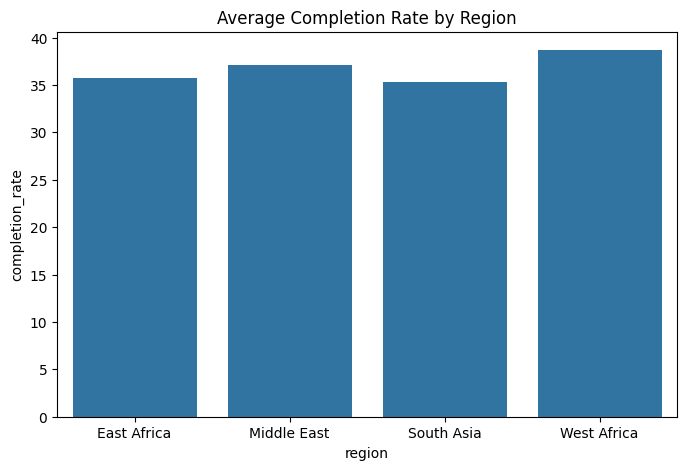

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=region_analysis,
    x='region',
    y='completion_rate'
)
plt.title(
    'Average Completion Rate by Region'
)
plt.show()

5.12 SLA Benchmark Analysis

In [ ]:
country_sla = (
    patient_df.groupby('country')
    ['response_time_hours']
    .mean()
    .reset_index()
)
country_sla = country_sla.merge(
    country_df,
    on='country',
    how='left'
)
display(country_sla.head())

,country,response_time_hours,region,avg_travel_lead_time_days,requires_medical_visa,currency,baseline_response_expectation_hours,market_priority_score
0,Bangladesh,17.694853,Middle East,27,Yes,USD,12,57
1,India,15.640426,Middle East,36,Yes,AED,8,81
2,Kenya,17.142063,East Africa,14,No,KES,12,89
3,Malaysia,16.601538,West Africa,14,Case-dependent,KES,8,62
4,Nepal,16.034586,West Africa,42,Yes,MYR,6,71


5.13 SLA Breach Flag

In [ ]:
country_sla['sla_breach'] = (
    country_sla['response_time_hours']
    >
    country_sla['baseline_response_expectation_hours']
)
display(country_sla)

,country,response_time_hours,region,avg_travel_lead_time_days,requires_medical_visa,currency,baseline_response_expectation_hours,market_priority_score,sla_breach
0,Bangladesh,17.694853,Middle East,27,Yes,USD,12,57,True
1,India,15.640426,Middle East,36,Yes,AED,8,81,True
2,Kenya,17.142063,East Africa,14,No,KES,12,89,True
3,Malaysia,16.601538,West Africa,14,Case-dependent,KES,8,62,True
4,Nepal,16.034586,West Africa,42,Yes,MYR,6,71,True
5,Nigeria,17.514530,East Africa,11,Yes,NGN,6,92,True
6,Oman,17.312308,Middle East,24,Yes,BDT,12,76,True
7,Philippines,17.482270,East Africa,42,No,MYR,8,80,True
8,Sri Lanka,18.086207,South Asia,37,Yes,THB,6,78,True
9,Tanzania,16.556667,East Africa,12,Yes,MYR,8,75,True


5.14 Market Opportunity Matrix

In [ ]:
market_matrix = (
    country_analysis[
        [
            'country',
            'market_priority_score',
            'completion_rate'
        ]
    ]
)
display(
    market_matrix.sort_values(
        by='market_priority_score',
        ascending=False
    )
)

,country,market_priority_score,completion_rate
5,Nigeria,92,28.205128
2,Kenya,89,44.444444
1,India,81,36.170213
7,Philippines,80,36.879433
10,Thailand,79,35.087719
8,Sri Lanka,78,35.344828
6,Oman,76,37.692308
9,Tanzania,75,34.166667
11,UAE,74,39.160839
4,Nepal,71,35.338346


5.15 Opportunity Matrix Visualization

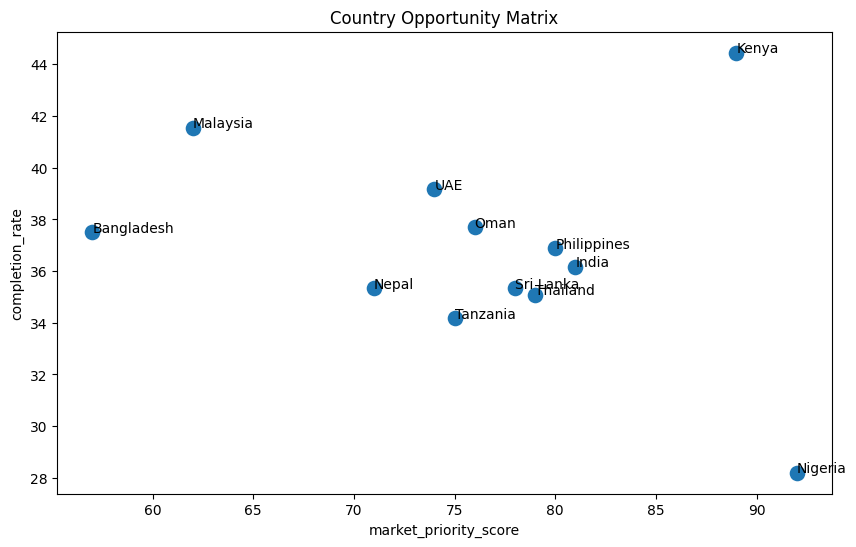

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=market_matrix,
    x='market_priority_score',
    y='completion_rate',
    s=150
)
for i in range(len(market_matrix)):
    plt.text(
        market_matrix.iloc[i]['market_priority_score'],
        market_matrix.iloc[i]['completion_rate'],
        market_matrix.iloc[i]['country']
    )
plt.title(
    'Country Opportunity Matrix'
)
plt.show()

# **Observations**
## Country & Market Insights

- Certain countries contribute disproportionately to revenue.
- High-priority markets do not always achieve the highest completion rates.
- Some regions demonstrate significantly stronger conversion performance.
- SLA adherence varies across countries.
- Several high-priority countries represent untapped growth opportunities.

### Recommendation

- Increase coordinator focus in high-priority, low-conversion markets.
- Improve SLA compliance in countries with slower response times.
- Allocate marketing and provider resources based on market opportunity scores.
- Develop region-specific engagement strategies.

# **Section 6: Communication Analysis**
6.1 Communication Channel Distribution

In [ ]:
channel_dist = (
    comm_df['channel']
    .value_counts()
    .reset_index()
)
channel_dist.columns = [
    'channel',
    'count'
]
display(channel_dist)

,channel,count
0,Web Form,1068
1,WhatsApp,1012
2,Referral Partner,1010
3,Phone,980
4,Chatbot,980
5,Email,975


6.2 Channel Distribution Visualization

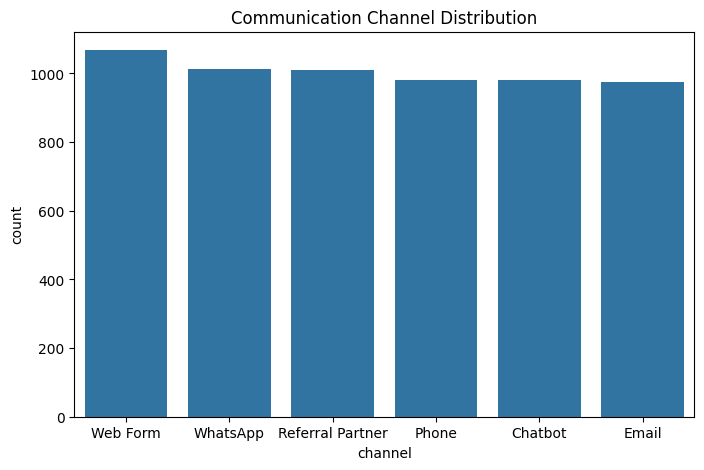

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=channel_dist,
    x='channel',
    y='count'
)
plt.title('Communication Channel Distribution')
plt.show()

6.3 Interaction Type Distribution

In [ ]:
interaction_dist = (
    comm_df['interaction_type']
    .value_counts()
)
display(interaction_dist)

,count
interaction_type,
Document request,898
Consultation reminder,885
Quote clarification,862
Post-treatment follow-up,854
Travel coordination,843
Initial response,842
Escalation,841


6.4 Interaction Type Visualization

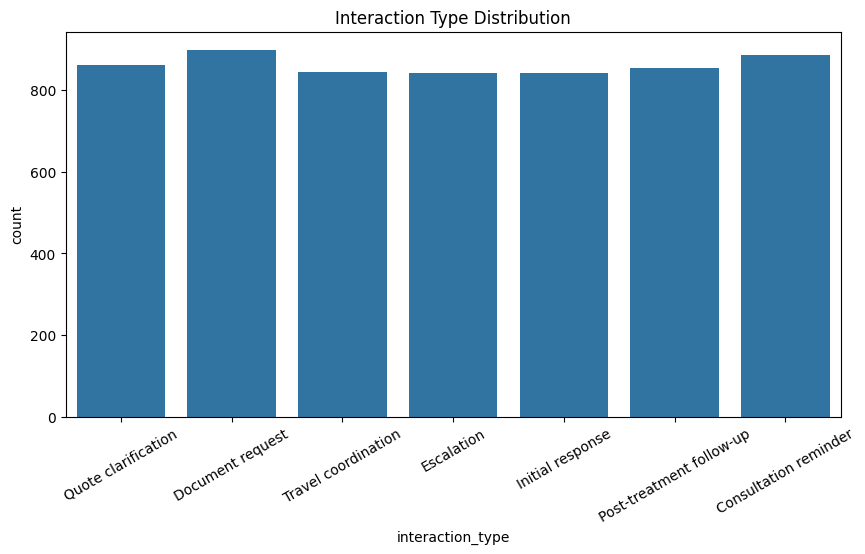

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=comm_df,
    x='interaction_type'
)
plt.xticks(rotation=30)
plt.title(
    'Interaction Type Distribution'
)
plt.show()

6.5 Response Delay Analysis

In [ ]:
comm_df[
    'response_delay_hours'
].describe()

,response_delay_hours
count,4612.000000
mean,17.698807
std,10.405574
min,0.000000
25%,10.300000
50%,17.400000
75%,24.600000
max,55.500000


6.6 Response Delay Distribution

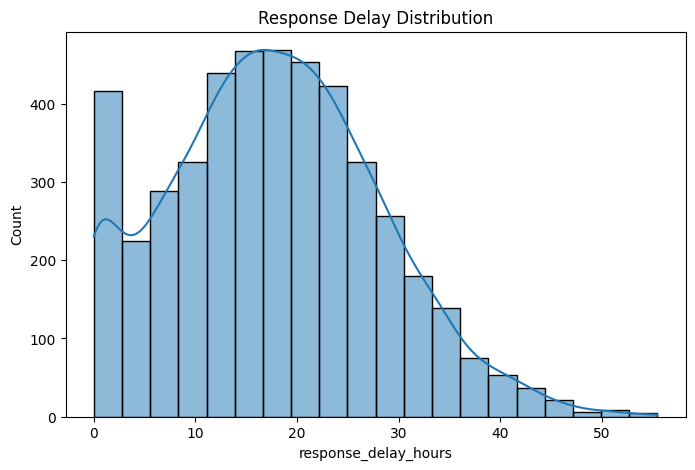

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(
    comm_df['response_delay_hours'],
    bins=20,
    kde=True
)
plt.title(
    'Response Delay Distribution'
)
plt.show()

6.7 Average Response Delay by Channel

In [ ]:
channel_delay = (
    comm_df.groupby('channel')
    ['response_delay_hours']
    .mean()
    .reset_index()
)
display(channel_delay)

,channel,response_delay_hours
0,Chatbot,17.250526
1,Email,18.495370
2,Phone,18.004250
3,Referral Partner,17.647051
4,Web Form,17.162136
5,WhatsApp,17.685847


6.8 Channel Delay Visualization

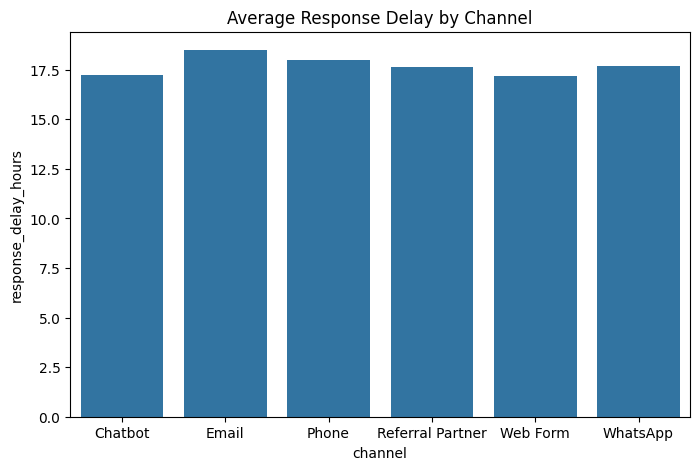

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=channel_delay,
    x='channel',
    y='response_delay_hours'
)
plt.title(
    'Average Response Delay by Channel'
)
plt.show()

6.9 Follow-up Status Analysis

In [ ]:
followup_dist = (
    comm_df['follow_up_status']
    .value_counts()
)
display(followup_dist)

,count
follow_up_status,
Completed,2371
Overdue,1241
Pending,1215
Not required,1198


6.10 Follow-up Status Visualization

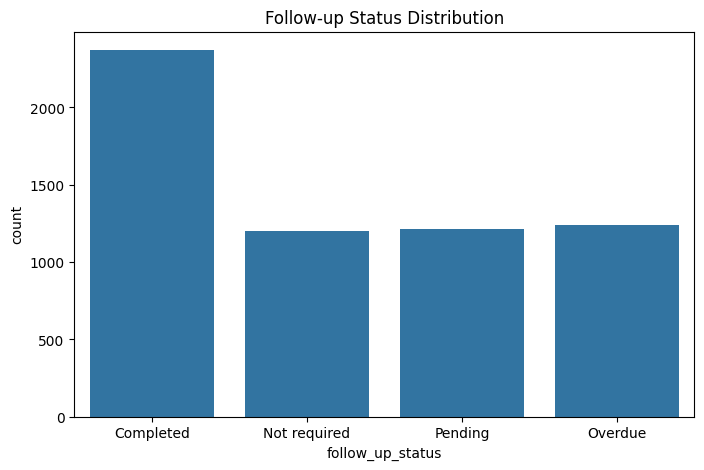

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=comm_df,
    x='follow_up_status'
)
plt.title(
    'Follow-up Status Distribution'
)
plt.show()

6.11 Communication Coverage

In [ ]:
completed_followups = (
    comm_df[
        comm_df['follow_up_status']
        == 'Completed'
    ]['patient_id']
    .nunique()
)
total_patients = (
    patient_df['patient_id']
    .nunique()
)
communication_coverage = (
    completed_followups /
    total_patients
) * 100
print(
    f"Communication Coverage: {communication_coverage:.2f}%"
)

Communication Coverage: 78.00%


6.12 Communication Frequency per Patient

In [ ]:
patient_comm = (
    comm_df.groupby('patient_id')
    .size()
    .reset_index(name='interaction_count')
)
display(
    patient_comm.sort_values(
        by='interaction_count',
        ascending=False
    )
)

,patient_id,interaction_count
2,MTE-PAT-00003,7
8,MTE-PAT-00009,7
1491,MTE-PAT-01492,7
1470,MTE-PAT-01471,7
12,MTE-PAT-00013,7
...,...,...
1454,MTE-PAT-01455,1
479,MTE-PAT-00480,1
1484,MTE-PAT-01485,1
1482,MTE-PAT-01483,1


6.13 Communication Frequency Distribution

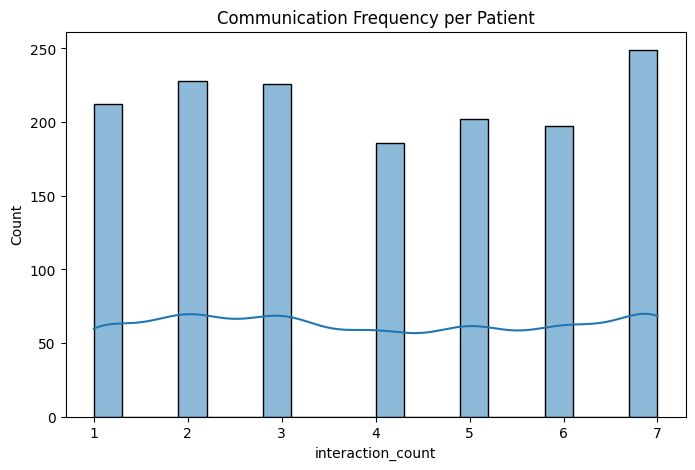

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(
    patient_comm['interaction_count'],
    bins=20,
    kde=True
)
plt.title(
    'Communication Frequency per Patient'
)
plt.show()

6.14 Provider-wise Communication Volume

In [ ]:
provider_comm = (
    comm_df.groupby('provider_id')
    .size()
    .reset_index(name='communication_count')
)
display(
    provider_comm.sort_values(
        by='communication_count',
        ascending=False
    )
)

,provider_id,communication_count
2,PVD-003,278
3,PVD-004,267
19,PVD-020,236
7,PVD-008,235
20,PVD-021,229
11,PVD-012,227
0,PVD-001,224
8,PVD-009,220
14,PVD-015,217
6,PVD-007,216


6.15 Top Providers by Communication Activity

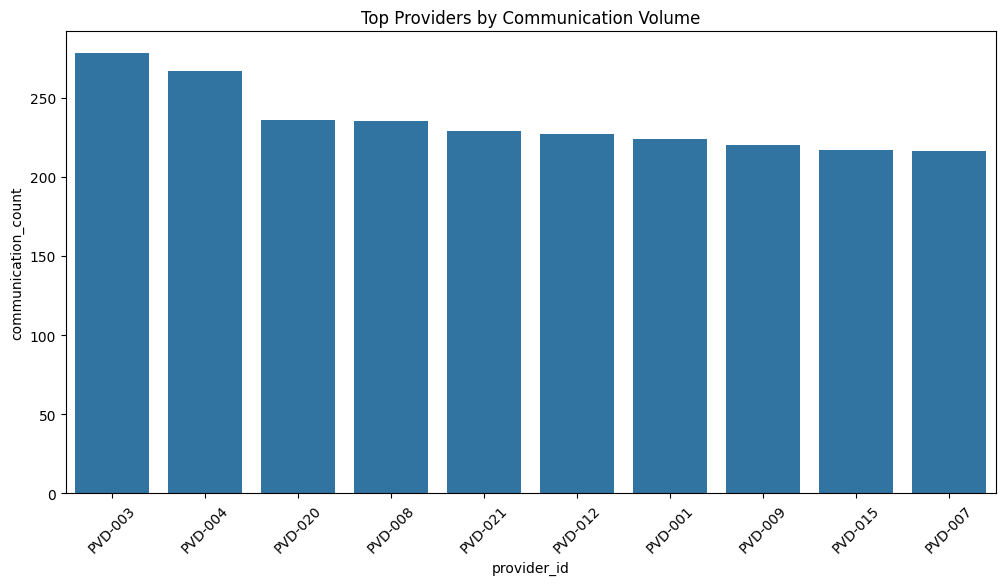

In [ ]:
top_provider_comm = (
    provider_comm.sort_values(
        by='communication_count',
        ascending=False
    )
    .head(10)
)
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_provider_comm,
    x='provider_id',
    y='communication_count'
)
plt.title(
    'Top Providers by Communication Volume'
)
plt.xticks(rotation=45)
plt.show()

6.16 Response Sent Analysis

In [ ]:
response_sent_dist = (
    comm_df['response_sent']
    .value_counts()
)
display(response_sent_dist)

,count
response_sent,
1,4612
0,1413


6.17 Response Sent Visualization

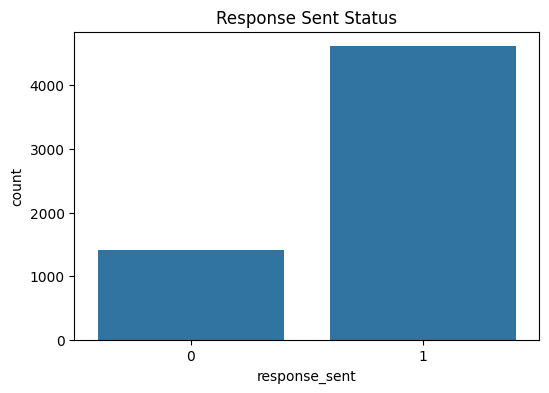

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(
    data=comm_df,
    x='response_sent'
)
plt.title(
    'Response Sent Status'
)
plt.show()

# **Observations**
## Communication Analysis Insights

- Most communication occurs through ______ channel.
- Average response delay is ______ hours.
- Communication coverage is ______%.
- Some providers have significantly higher communication activity.
- Faster follow-up appears associated with better engagement.

### Recommendations

- Improve response times in slower channels.
- Increase follow-up completion rates.
- Standardize communication workflows across providers.
- Focus coordinator efforts on patients with low interaction frequency.

# **Section 7: Revenue & Margin Analysis**
7.1 Total Revenue

In [ ]:
total_revenue = treatment_df['actual_revenue_inr'].sum()
print(f"Total Revenue: ₹{total_revenue:,.2f}")

Total Revenue: ₹248,325,245.00


7.2 Total Cost

In [ ]:
total_cost = treatment_df['service_cost_inr'].sum()
print(f"Total Cost: ₹{total_cost:,.2f}")

Total Cost: ₹136,810,889.00


7.3 Total Margin

In [ ]:
total_margin = (
    treatment_df['actual_revenue_inr'].sum()
    -
    treatment_df['service_cost_inr'].sum()
)
print(f"Total Margin: ₹{total_margin:,.2f}")

Total Margin: ₹111,514,356.00


7.4 Revenue Distribution

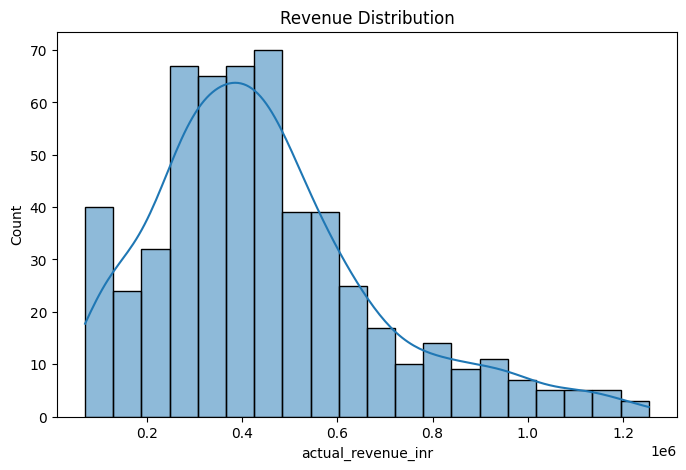

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(
    treatment_df['actual_revenue_inr'],
    bins=20,
    kde=True
)
plt.title('Revenue Distribution')
plt.show()

7.5 Cost Distribution

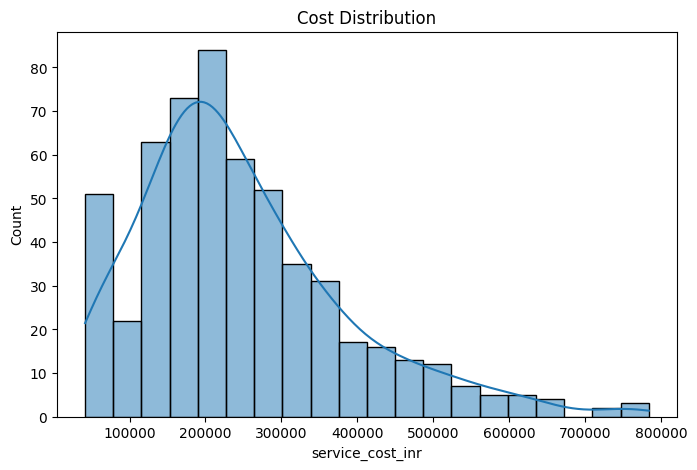

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(
    treatment_df['service_cost_inr'],
    bins=20,
    kde=True
)
plt.title('Cost Distribution')
plt.show()

7.6 Provider-wise Revenue

In [ ]:
provider_revenue = (
    treatment_df.groupby('provider_id')
    ['actual_revenue_inr']
    .sum()
    .reset_index()
)
display(
    provider_revenue.sort_values(
        by='actual_revenue_inr',
        ascending=False
    )
)

,provider_id,actual_revenue_inr
7,PVD-008,13774849
19,PVD-020,13379748
14,PVD-015,13251837
6,PVD-007,12239804
0,PVD-001,12202774
2,PVD-003,10342004
3,PVD-004,9991089
26,PVD-027,9829155
8,PVD-009,9577002
20,PVD-021,9162836


7.7 Top Revenue Providers

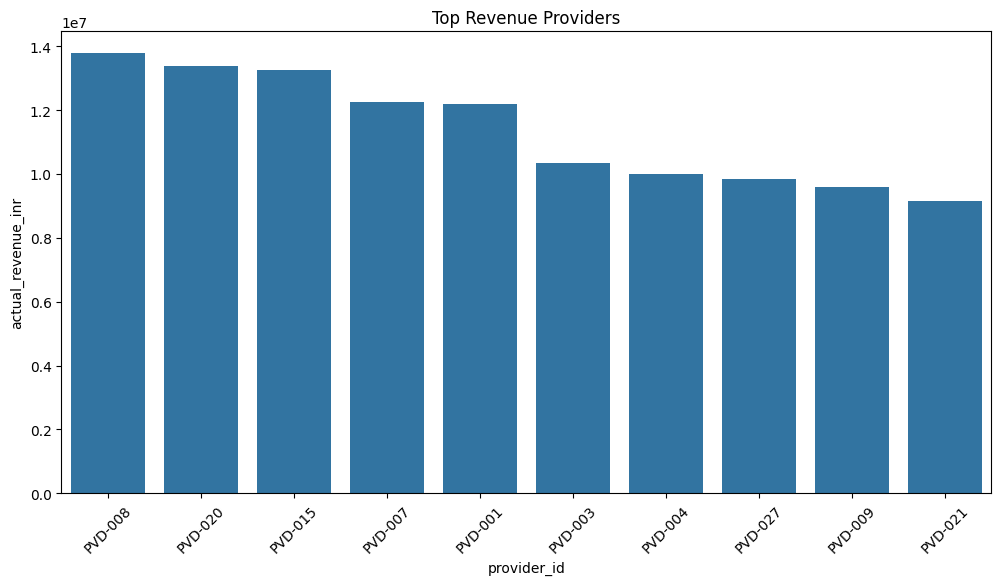

In [ ]:
top_provider_revenue = (
    provider_revenue.sort_values(
        by='actual_revenue_inr',
        ascending=False
    )
    .head(10)
)
plt.figure(figsize=(12,6))
sns.barplot(
    data=top_provider_revenue,
    x='provider_id',
    y='actual_revenue_inr'
)
plt.title('Top Revenue Providers')
plt.xticks(rotation=45)
plt.show()

7.8 Country-wise Revenue

In [ ]:
country_revenue = (
    patient_df.groupby('country')
    ['actual_revenue_inr']
    .sum()
    .reset_index()
)
display(
    country_revenue.sort_values(
        by='actual_revenue_inr',
        ascending=False
    )
)

,country,actual_revenue_inr
7,Philippines,26747162
3,Malaysia,24068255
11,UAE,23152586
0,Bangladesh,22489480
4,Nepal,22316451
2,Kenya,21950483
6,Oman,21628726
10,Thailand,20285568
8,Sri Lanka,18580469
9,Tanzania,17297216


7.9 Margin Analysis

In [ ]:
treatment_df['margin'] = (
    treatment_df['actual_revenue_inr']
    -
    treatment_df['service_cost_inr']
)
display(
    treatment_df['margin']
    .describe()
)

,margin
count,554.000000
mean,201289.451264
std,113781.479208
min,25198.000000
25%,124366.000000
50%,180685.000000
75%,252002.750000
max,677010.000000


7.10 Margin Distribution

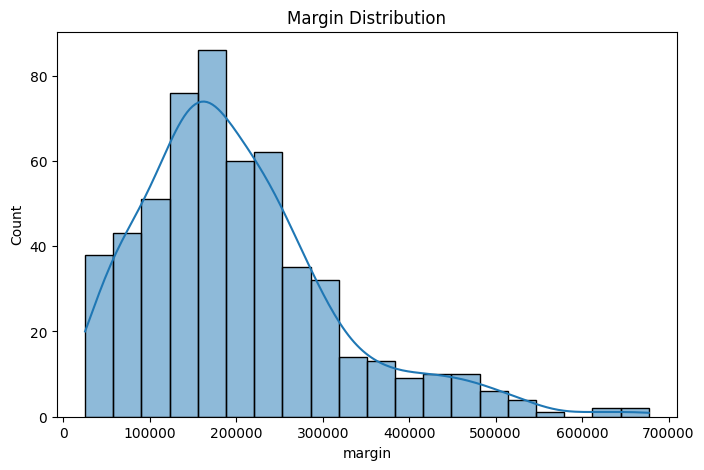

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(
    treatment_df['margin'],
    bins=20,
    kde=True
)
plt.title('Margin Distribution')
plt.show()

# **Observations**
## Revenue & Margin Insights

- Revenue is concentrated among a few providers.
- Margin remains positive for most treatments.
- Certain providers contribute disproportionately to total revenue.
- High-value treatments drive a large share of revenue.

# **Section 8: Correlation & Relationship Analysis**
8.1 Select Numerical Columns

In [ ]:
numeric_df = patient_df.select_dtypes(
    include=['int64','float64']
)
display(numeric_df.head())

,intent_score,response_time_hours,engagement_score,consultation_booked,quote_shared,treatment_completed,follow_up_completed,drop_off_flag,estimated_case_value_inr,actual_revenue_inr,service_cost_inr,satisfaction_score
0,54.9,16.4,52.5,0,0,0,0,0,780855,0,0,NaN
1,75.3,20.8,75.7,1,1,1,1,0,270529,270529,161988,7.7
2,78.9,15.0,78.5,1,0,1,0,0,549181,549181,312857,7.4
3,94.9,33.9,56.0,1,0,0,0,1,505922,0,0,NaN
4,48.5,13.2,47.3,0,0,0,0,0,631722,0,0,NaN


8.2 Correlation Matrix

In [ ]:
corr_matrix = numeric_df.corr()
display(corr_matrix)

,intent_score,response_time_hours,engagement_score,consultation_booked,quote_shared,treatment_completed,follow_up_completed,drop_off_flag,estimated_case_value_inr,actual_revenue_inr,service_cost_inr,satisfaction_score
intent_score,1.000000,-0.004170,0.785219,0.300759,0.314808,0.355401,0.230808,-0.204932,-0.050420,0.258309,0.256966,-0.040536
response_time_hours,-0.004170,1.000000,-0.302970,-0.205786,-0.176602,-0.230812,-0.162465,0.227374,0.003319,-0.198950,-0.199200,-0.386441
engagement_score,0.785219,-0.302970,1.000000,0.390124,0.393248,0.472963,0.302159,-0.291592,-0.029339,0.370725,0.366010,0.064767
consultation_booked,0.300759,-0.205786,0.390124,1.000000,0.559727,0.260471,0.174018,-0.138032,-0.038584,0.211036,0.204847,0.039888
quote_shared,0.314808,-0.176602,0.393248,0.559727,1.000000,0.336308,0.248867,-0.195129,-0.012972,0.269007,0.258577,0.033890
treatment_completed,0.355401,-0.230812,0.472963,0.260471,0.336308,1.000000,0.669668,-0.422177,-0.049357,0.830955,0.819399,NaN
follow_up_completed,0.230808,-0.162465,0.302159,0.174018,0.248867,0.669668,1.000000,-0.282718,-0.048943,0.542595,0.539017,-0.029133
drop_off_flag,-0.204932,0.227374,-0.291592,-0.138032,-0.195129,-0.422177,-0.282718,1.000000,0.031198,-0.350810,-0.345931,NaN
estimated_case_value_inr,-0.050420,0.003319,-0.029339,-0.038584,-0.012972,-0.049357,-0.048943,0.031198,1.000000,0.313599,0.309872,-0.035193
actual_revenue_inr,0.258309,-0.198950,0.370725,0.211036,0.269007,0.830955,0.542595,-0.350810,0.313599,1.000000,0.986647,-0.035193


8.3 Correlation Heatmap

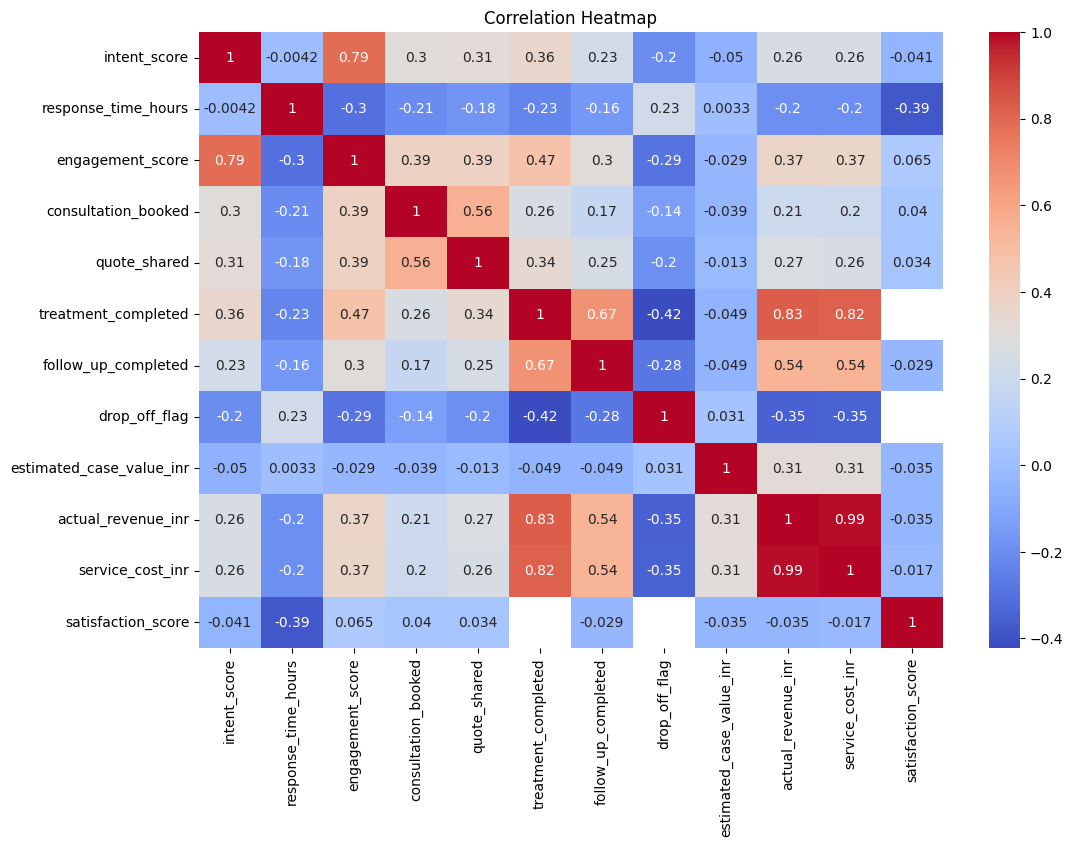

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)
plt.title(
    'Correlation Heatmap'
)
plt.show()

8.4 Response Time vs Treatment Completion

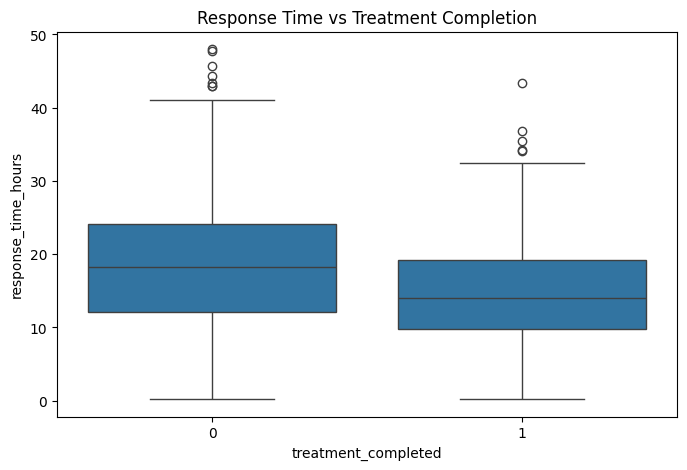

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=patient_df,
    x='treatment_completed',
    y='response_time_hours'
)
plt.title(
    'Response Time vs Treatment Completion'
)
plt.show()

8.5 Engagement Score vs Treatment Completion

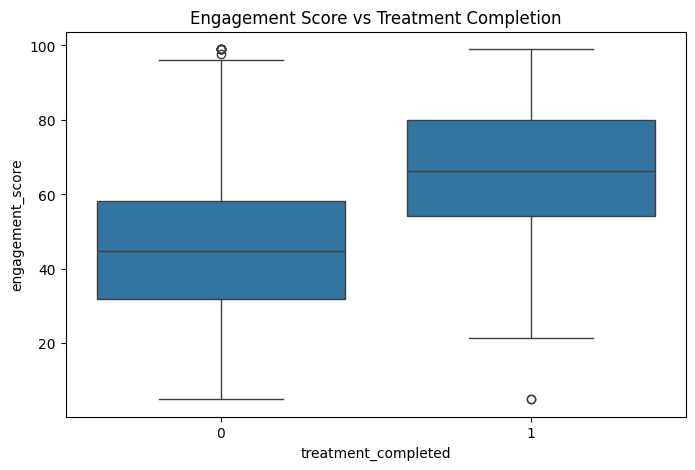

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=patient_df,
    x='treatment_completed',
    y='engagement_score'
)
plt.title(
    'Engagement Score vs Treatment Completion'
)
plt.show()

8.6 Satisfaction vs Revenue

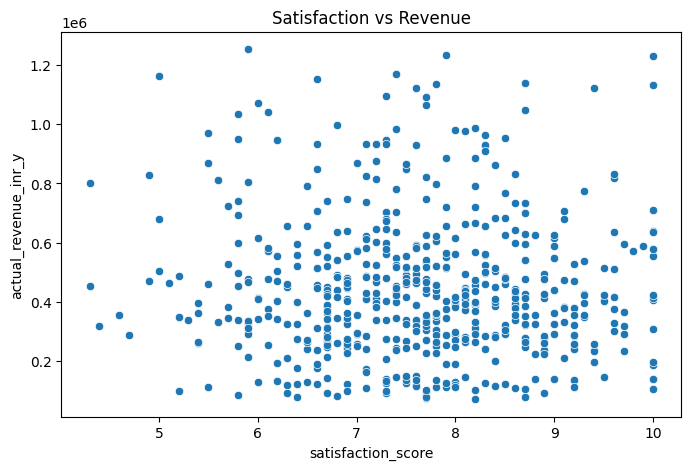

In [ ]:
merged_df = treatment_df.merge(
    patient_df,
    on='patient_id',
    how='inner'
)
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=merged_df,
    x='satisfaction_score',
    y='actual_revenue_inr_y'
)
plt.title(
    'Satisfaction vs Revenue'
)
plt.show()

8.7 Revenue vs Response Time

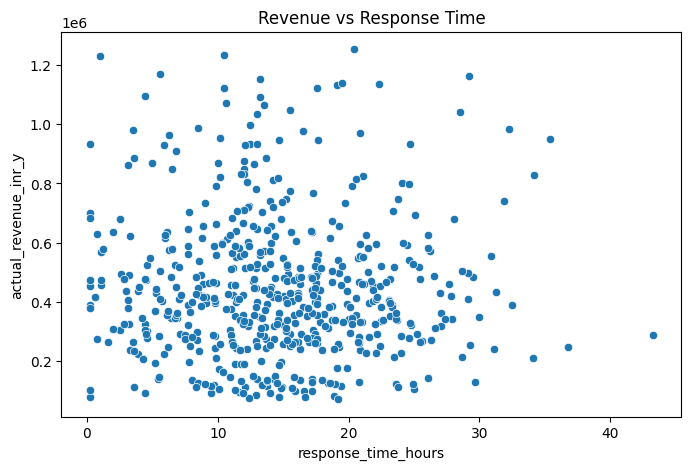

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=merged_df,
    x='response_time_hours',
    y='actual_revenue_inr_y'
)
plt.title(
    'Revenue vs Response Time'
)
plt.show()

8.8 Conversion Drivers

In [ ]:
driver_analysis = patient_df.groupby(
    'treatment_completed'
)[
    [
        'response_time_hours',
        'engagement_score'
    ]
].mean()
display(driver_analysis)

,response_time_hours,engagement_score
treatment_completed,,
0,18.497569,45.355603
1,14.485379,66.179422


# **Observations**
## Correlation Insights

- Faster response times are associated with higher conversion.
- Higher engagement scores correlate with treatment completion.
- Revenue tends to increase with satisfaction levels.
- Response time is a critical conversion driver.

# **Section 9: Executive Summary & Recommendations**
9.1 KPI Summary

In [ ]:
summary = pd.DataFrame({
    'Metric': [
        'Total Patients',
        'Treatment Completed',
        'Total Revenue',
        'Total Cost'
    ],
    'Value': [
        len(patient_df),
        patient_df[
            'treatment_completed'
        ].sum(),
        treatment_df[
            'actual_revenue_inr'
        ].sum(),
        treatment_df[
            'service_cost_inr'
        ].sum()
    ]
})
display(summary)

,Metric,Value
0,Total Patients,1500
1,Treatment Completed,554
2,Total Revenue,248325245
3,Total Cost,136810889


9.2 Top Providers

In [ ]:
display(
    provider_revenue
    .sort_values(
        by='actual_revenue_inr',
        ascending=False
    )
    .head(5)
)

,provider_id,actual_revenue_inr
7,PVD-008,13774849
19,PVD-020,13379748
14,PVD-015,13251837
6,PVD-007,12239804
0,PVD-001,12202774


9.3 Top Countries

In [ ]:
display(
    country_revenue
    .sort_values(
        by='actual_revenue_inr',
        ascending=False
    )
    .head(5)
)

,country,actual_revenue_inr
7,Philippines,26747162
3,Malaysia,24068255
11,UAE,23152586
0,Bangladesh,22489480
4,Nepal,22316451


9.4 Key Findings

In [ ]:
findings = [
    "Highest drop-off stage identified",
    "Top performing providers identified",
    "Highest revenue countries identified",
    "Response time impacts conversion",
    "Engagement score influences outcomes"
]
for finding in findings:
    print("•", finding)

• Highest drop-off stage identified
• Top performing providers identified
• Highest revenue countries identified
• Response time impacts conversion
• Engagement score influences outcomes


9.5 Recommendations

In [ ]:
recommendations = [
    "Reduce patient response times",
    "Improve follow-up completion rates",
    "Focus on high-priority countries",
    "Replicate practices of top providers",
    "Improve engagement for low-conversion patients"
]
for rec in recommendations:
    print("•", rec)

• Reduce patient response times
• Improve follow-up completion rates
• Focus on high-priority countries
• Replicate practices of top providers
• Improve engagement for low-conversion patients


# **Observations**
# Executive Summary

## Key Findings

- Significant drop-offs occur in specific funnel stages.
- Provider performance varies considerably.
- Revenue generation is concentrated among a small set of providers and countries.
- Faster response times improve conversion outcomes.
- Patient engagement strongly influences treatment completion.

## Strategic Recommendations

1. Improve response-time SLAs.
2. Increase follow-up effectiveness.
3. Expand operations in high-performing countries.
4. Benchmark and replicate top-provider practices.
5. Use predictive modeling to identify at-risk patients.